# Model selection with correlational data

Companion notebook for **"Reliable data clustering with Bayesian community detection"** (Neuman, Smiljanić & Rosvall).

Given noisy similarity data, this notebook shows the one-step approach from the paper: it uses the **Regularized Map Equation** to pick the correlation threshold and the clusters at the same time, by maximizing the description-length compression. The steps are:

1. generate synthetic correlational data with a known (planted) cluster structure,
2. compare the observed correlations with the theoretical within- and between-cluster distributions,
3. scan thresholds and pick the one that compresses the description length most,
4. infer the clusters at that threshold and compare them with the planted structure.

We threshold on the **absolute** correlation, so negative correlations are kept.

**Requirements:** `numpy`, `scipy`, `scikit-learn`, `matplotlib`, `networkx` (>= 3.0, for `from_numpy_array`), and `infomap` (https://www.mapequation.org). Tested with Python 3.10.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
import infomap
from scipy.special import hyp2f1, gammaln
from sklearn.metrics import adjusted_mutual_info_score

## Helper functions

`pdf_hotelling` is the exact sampling density of the Pearson correlation (Methods Eq. (6)); it works in log space with `gammaln` so the gamma factors do not overflow for large `L`. `intersection_threshold` is the closed form for the crossing point `r_i`. `build_network` thresholds the correlation matrix, and `compression_reg_map_eq` runs the Regularized Map Equation over a range of thresholds.

In [2]:
def pdf_hotelling(r, L, rho):
    """Exact sampling density of the Pearson correlation (Hotelling), Methods Eq. (6).

    Works in log space with gammaln so the gamma factors never overflow for large L.
    """
    log_prefactor = (
        np.log(L - 2)
        + gammaln(L - 1)
        + 0.5 * (L - 1) * np.log(1 - rho ** 2)
        + 0.5 * (L - 4) * np.log(1 - r ** 2)
        - 0.5 * np.log(2 * np.pi)
        - gammaln(L - 0.5)
        - 0.5 * (2 * L - 3) * np.log(1 - rho * r)
    )
    return np.exp(log_prefactor) * hyp2f1(0.5, 0.5, (2 * L - 1) / 2, (rho * r + 1) / 2)


def intersection_threshold(L, rho, q, N):
    """Correlation r_i where the within- and between-cluster distributions cross."""
    return 1 / rho - (
        (1 - q / N) ** (2 / (2 * L - 3)) * (1 - rho ** 2) ** ((L - 1) / (2 * L - 3))
    ) / (rho * (q - 1) ** (2 / (2 * L - 3)))


def build_network(Sigma_hat, tau):
    """Unweighted network from correlations with |r| > tau (self-links removed).

    We threshold on the absolute correlation so negative correlations are kept, and
    we use unweighted links because the Dirichlet prior of the Regularized Map
    Equation is defined for these (Infomap also runs with weighted links).
    """
    A = (np.abs(Sigma_hat) > tau).astype(int)
    np.fill_diagonal(A, 0)
    return nx.from_numpy_array(A)


def compression_reg_map_eq(tau_range, Sigma_hat):
    """Description-length compression and module count over a range of thresholds."""
    compression = np.zeros(len(tau_range))
    n_modules = np.zeros(len(tau_range), dtype=int)
    for i, tau in enumerate(tau_range):
        G = build_network(Sigma_hat, tau)
        im = infomap.Infomap(two_level=True, regularized=True, silent=True)
        im.add_networkx_graph(G)
        im.run()
        savings = im.relative_codelength_savings
        compression[i] = 0.0 if np.isnan(savings) else savings  # nan if the network has no links
        n_modules[i] = im.num_top_modules
    return compression, n_modules

## Generate synthetic correlational data

We draw `L` samples of `N` features from a multivariate normal with a block-diagonal covariance: features in the same cluster have population correlation `rho`, features in different clusters are uncorrelated. The observed correlation matrix is the input for inference.

In [3]:
rng = np.random.default_rng(0)  # fix the seed for reproducibility

N, q, rho, L = 1000, 4, 0.2, 100
nodes_per_module = N // q

# planted partition: nodes_per_module nodes in each of q clusters
plantedPartition = np.repeat(np.arange(1, q + 1), nodes_per_module).tolist()

# block-diagonal covariance: rho within a cluster, 0 between clusters, 1 on the diagonal
block = np.full((nodes_per_module, nodes_per_module), rho)
np.fill_diagonal(block, 1.0)
zero = np.zeros((nodes_per_module, nodes_per_module))
cov = np.block([[block if i == j else zero for j in range(q)] for i in range(q)])

# sample L observations and form the observed correlation matrix
X = rng.multivariate_normal(np.zeros(N), cov, size=L)
Sigma_hat = np.corrcoef(X, rowvar=False)  # equals X^T X / (L-1) for standardized columns

## Correlation distributions

The observed correlations are a mix of the within-cluster distribution (population correlation `rho`) and the between-cluster distribution (population correlation 0). They cross at `r_i`. When the two distributions overlap a lot, the clusters are hard to recover.

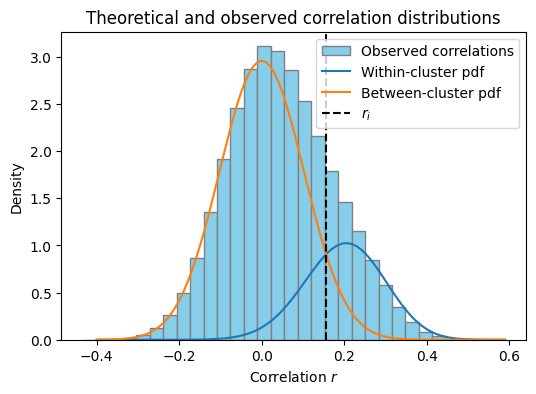

In [4]:
r_range = np.arange(-0.4, 0.6, 0.01)
within = N / (N - 1) * (1 / q - 1 / N) * pdf_hotelling(r_range, L, rho)
between = N / (N - 1) * (1 - 1 / q) * pdf_hotelling(r_range, L, 0.0)
r_i = intersection_threshold(L, rho, q, N)

corr_values = Sigma_hat[np.triu_indices_from(Sigma_hat, k=1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(corr_values, bins=30, density=True, color='skyblue', edgecolor='gray',
        label='Observed correlations')
ax.plot(r_range, within, label='Within-cluster pdf')
ax.plot(r_range, between, label='Between-cluster pdf')
ax.axvline(r_i, color='k', linestyle='--', label=r'$r_i$')
ax.set_xlabel('Correlation $r$')
ax.set_ylabel('Density')
ax.set_title('Theoretical and observed correlation distributions')
ax.legend()
plt.show()

## Threshold selection by description-length compression

For each threshold we build the network and run the Regularized Map Equation. The threshold with the largest compression, `tau*`, is the one we keep.

Optimal threshold tau* = 0.28


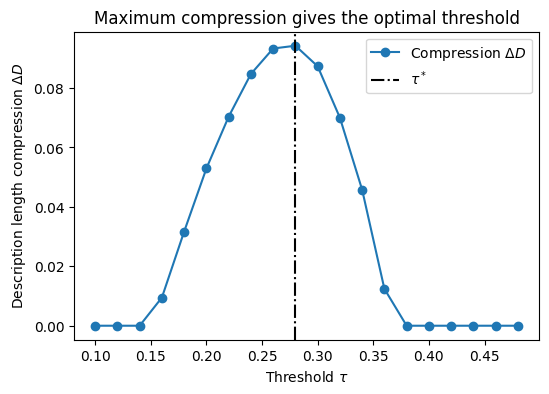

In [5]:
tau_range = np.arange(0.1, 0.5, 0.02)  # thresholds to try
compression, n_modules = compression_reg_map_eq(tau_range, Sigma_hat)
tau_star = round(float(tau_range[np.argmax(compression)]), 2)  # threshold at maximum compression
print(f'Optimal threshold tau* = {tau_star}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tau_range, compression, 'o-', label=r'Compression $\Delta D$')
ax.axvline(tau_star, color='k', linestyle='-.', label=r'$\tau^*$')
ax.set_xlabel(r'Threshold $\tau$')
ax.set_ylabel(r'Description length compression $\Delta D$')
ax.set_title('Maximum compression gives the optimal threshold')
ax.legend()
plt.show()

## Infer and visualize the clusters

We build the network at `tau*`, infer the clusters, and compare them with the planted partition using the adjusted mutual information (AMI). AMI = 1 is a perfect match.

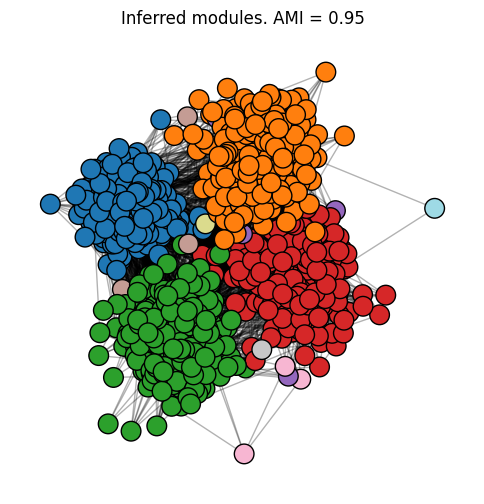

In [6]:
G = build_network(Sigma_hat, tau_star)
im = infomap.Infomap(two_level=True, regularized=True, silent=True, num_trials=1)  # raise num_trials if the result varies
im.add_networkx_graph(G)
im.run()

module_of_node = dict(im.modules)  # {node id: module id}
nx.set_node_attributes(G, module_of_node, 'module')
node_colors = [module_of_node.get(node, -1) for node in G.nodes()]

ami = adjusted_mutual_info_score(plantedPartition, node_colors)

fig, ax = plt.subplots(figsize=(6, 6))
pos = nx.spring_layout(G, seed=0)  # fix layout for reproducibility
nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=mpl.colormaps['tab20'],
                       node_size=200, edgecolors='black', ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.3, ax=ax)
ax.set_title(f'Inferred modules. AMI = {ami:.2f}')
ax.axis('off')
plt.show()